# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria
Completá al menos una entrada en este registro por cada parte del laboratorio.

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué responidó (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** |- Definir un esquema común de columnas al unificar fuentes distintas en un DataFrame - Resolver por qué el trabajo con playwright no generaba el json |- Qué mejoras debo realizar para que los datos de distintas fuentes tengan un formato coherente en una integración - Le pedí ayuda para comprender por qué en la vista de la terminal figuraban las fuentes scrapeadas, pero no aparece el mensaje de "Archivo generado". |- Me sugirió el uso de urlparse para trabajar con las urls - También propuso el código corregido y la explicación para generar el JSON correctamente. |- El uso de urlparse lo dejé en las noticias escritas. - Mantuve la sugerencia para poder generar el JSON.|- Descarté el uso de la librería en la presentación del audio por un error que al menos no pude resolver al momento de la entrega.|- Podría haber rehecho ajustes en el código para mantener la consistencia de los datos.|
| **Parte 2** |Criterios de clasificación para spaCy|Cómo podemos tratar la información que extraemos del corpus con spaCy. Además le consulté cómo poder trabajar la pausa de auditoría de esta parte.|Respondió con los criterios teóricos de clasificación para PER, ORG y LOC, y recomendó verificarlos contra la salida real del modelo. Respecto a la pausa de auditoría, recomendó trabajar con las estadísticas.|En el análisis de la estadística visualicé algunos falsos positivos, pero no sabía de qué texto provenían. El asistente recomendó un código para visualizarlo, el cual corrí para comprender. |No modifiqué el modelo de spaCy ni entrené uno nuevo para esta entrega. |Al visualizar los resultados podría haber trabajado manualmente algunos falsos positivos. Además, los modelos de spaCy cometen más errores en texto transcrito por Whisper que en texto periodístico.|
| **Parte 3** |Esquematizar gráficos que sean claros y permitan comunicar resultados del análisis. |Qué gráficos conviene utilizar para la toma de decisiones? Sabiendo que en este caso es para un informe escolar. |Recomendó Barplot por mayor precisión comparativa. WordCloud tiene Data-Ink Ratio bajo porque posición y color no comunican datos. También propuso Lollipop Chart como variante superadora del barplot clásico |El Lollipop Chart porque combina precisión del barplot con menos tinta que las barras sólidas. | WordCloud es visualmente atractivo pero no permite comparar magnitudes con precisión, no sirve para decisiones| Que Data-Ink Ratio afecta directamente cuánta información útil comunica cada elemento visual. Un gráfico puede verse "lindo" y tener ratio bajo al mismo tiempo|
| **Parte 4** |Ordenar las funciones de las partes anteriores en una clase unificada y exportar los resultados |Qué debo tener en cuenta al momento de estructurar una clase que agrupe adquisición, análisis y exportación |Sugirió dividir en ejecutar_pipeline() y generar_reporte_y_exportar(). Además, al correr las pruebas, noté que otra vez se estaba descargando la transcripción del audio. |La separación en métodos y el código para que Whisper no vueva a correr. |Pasar url_audio directamente al pipeline - como Whisper ya había transcrito el video, opté por reutilizar df_corpus_completo asignándolo manualmente después de ejecutar_pipeline() para no repetir el proceso |La consistencia en nombres de variables entre métodos es muy importante, un df solo en el print rompió todo el pipeline hasta que lo identifiqué |
| **Parte 5** |Elegir el layout del dashboard y conectar el backend analítico con los componentes de Gradio |Qué layout es mejor para un dashboard evaluativo: pestañas, columna vertical o acordeón? Cómo muestro un gráfico de Plotly en Gradio?|Sugirió separar "Métricas generales" de "Explorador de entidades" para no sobrecargar una sola vista|Las pestañas y el buscador de entidades con filtrado dinámico - porque permite mostrar en vivo cómo el corpus responde a una búsqueda específica durante la exposición |El gráfico de entidades original con todas las entidades en un solo barplot - era ilegible por superposición de etiquetas, lo reemplacé por subplots separados por tipo (PER/ORG/LOC) con top 5 cada uno |Que un gráfico puede funcionar técnicamente y aun así fallar en comunicar y, obviamente, si los datos no están tratados previamente podemos sacar conclusiones erróneas|

In [1]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
%pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
!python -m spacy download es_core_news_lg -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\cin_c\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\cin_c\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
from urllib.parse import urlparse
import os

print("Librerías importadas correctamente.")

C:\Users\cin_c\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente.


## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
Para unificar las tres fuentes en un único DataFrame, elegí un esquema de columnas que muestren los datos mínimos, como titulo_o_fuente, texto, origen y url_path. 

In [3]:
def extraer_noticias_web(urls):
    """Extrae el texto de una lista de URLs usando Trafilatura"""
    noticias = []
    
    for url in urls:
        try:
            descarga = trafilatura.fetch_url(url)
            texto = trafilatura.extract(descarga, include_comments=False, include_images=False)
            
            if texto:
                noticias.append({
                    "titulo_o_fuente": urlparse(url).netloc.replace("www.", ""), #sugerencia del asistente para tener visible la url de la fuente
                    "texto": texto,
                    "origen": "web",
                    "url_o_path": url
                })
            else: 
                print (f"No se pudo extraer el texto de: {url}")
        except Exception as e:
            print(f"Ocurrió un error scrapeando {url}: {e}")
    return noticias

In [4]:
urls = [
    "https://www.infobae.com/educacion/2026/04/22/advierten-por-la-perdida-de-dias-de-clase-una-campana-busca-visibilizar-el-problema-y-reclama-datos-publicos/",
    "https://www.infobae.com/educacion/2026/04/09/crece-el-ausentismo-escolar-en-todo-el-pais-la-mitad-de-los-alumnos-falta-mas-de-15-dias-al-ano/",
    "https://www.infobae.com/educacion/2026/04/16/cada-ano-se-pierden-en-promedio-30-dias-de-clase-en-el-pais-advierten-por-el-impacto-en-el-aprendizaje/",
    "https://www.infobae.com/educacion/2026/04/24/amenazas-en-escuelas-portenas-se-recuperaran-los-dias-de-clase-perdidos-y-tendran-consecuencias-legales-los-padres/",
    "https://www.infobae.com/educacion/2025/12/06/ausentismo-cronico-uno-de-cada-tres-estudiantes-de-secundaria-falta-a-mas-del-10-de-las-clases/",
    "https://www.infobae.com/educacion/2025/10/29/alejandro-ganimian-y-el-problema-del-ausentismo-escolar-como-impacta-en-la-comprension-lectora-y-la-matematica/",
    "https://www.infobae.com/educacion/2026/04/21/carina-lion-el-rol-de-la-escuela-sigue-siendo-el-de-la-esperanza-el-de-dar-futuro-pero-no-un-futuro-distopico-sino-un-futuro-con-posibilidades/"
]

datos_web = extraer_noticias_web (urls)

df_web = pd.DataFrame(datos_web)

df_web.head()

,titulo_o_fuente,texto,origen,url_o_path
0,infobae.com,"Los estudiantes argentinos pierden, en promedi...",web,https://www.infobae.com/educacion/2026/04/22/a...
1,infobae.com,Lo advierten los docentes y lo reconocen los a...,web,https://www.infobae.com/educacion/2026/04/09/c...
2,infobae.com,"En Argentina, los estudiantes pierden en prome...",web,https://www.infobae.com/educacion/2026/04/16/c...
3,infobae.com,Los alumnos de escuelas de la Ciudad de Buenos...,web,https://www.infobae.com/educacion/2026/04/24/a...
4,infobae.com,"En la escuela secundaria, uno de cada tres est...",web,https://www.infobae.com/educacion/2025/12/06/a...


In [5]:
# 1.2 Transcripción de Audio usando el código del material de la cátedra
def youtube_a_texto(url: str, modelo_whisper: str = "small", idioma: str = "es", output_dir: str = "corpus") -> dict:
    # Pipeline completo: URL de YouTube -> audio -> transcripcion -> texto
    import json
    import os
    import re
    import shutil
    import whisper
    import yt_dlp

    os.makedirs(output_dir, exist_ok=True)

    if "preparar_ffmpeg" in globals():
        _, ffmpeg_dir, _ = preparar_ffmpeg()
    else:
        ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
        if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
            raise FileNotFoundError("No se encontro ffmpeg para ejecutar el pipeline completo.")
        ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
        if ffmpeg_dir not in os.environ.get("PATH", ""):
            os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    ydl_opts = {
        "format": "bestaudio/best",
        "noplaylist": True,
        "ffmpeg_location": ffmpeg_dir,
        "postprocessors": [
            {
                "key": "FFmpegExtractAudio",
                "preferredcodec": "mp3",
                "preferredquality": "192",
            }
        ],
        "outtmpl": f"{output_dir}/%(title)s.%(ext)s",
    }

    if "sanitizar_nombre_archivo" in globals():
        sanitizar = sanitizar_nombre_archivo
    else:
        def sanitizar(ruta_o_nombre: str, max_len: int = 80) -> str:
            nombre = os.path.splitext(os.path.basename(ruta_o_nombre))[0]
            invalidos = set('<>:/\\|?*') | {chr(34)}
            nombre = ''.join('_' if caracter in invalidos or ord(caracter) < 32 else caracter for caracter in nombre)
            nombre = re.sub(r'\s+', ' ', nombre).strip().rstrip('. ')
            return (nombre[:max_len] or 'transcripcion').strip()

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        titulo = info["title"]
        duracion = info["duration"]
        audio_generado = os.path.abspath(ydl.prepare_filename(info).rsplit(".", 1)[0] + ".mp3")

    print(f"Audio descargado: {titulo} ({duracion} segundos)")

    cache_modelos = globals().setdefault("_MODELOS_WHISPER", {})
    if modelo_whisper not in cache_modelos:
        cache_modelos[modelo_whisper] = whisper.load_model(modelo_whisper)
    modelo = cache_modelos[modelo_whisper]
    resultado_local = modelo.transcribe(audio_generado, language=idioma, fp16=False)
    print(f"Transcripcion completa: {len(resultado_local['segments'])} segmentos")

    nombre_base = sanitizar(audio_generado)
    ruta_txt = os.path.join(output_dir, f"{nombre_base}.txt")
    with open(ruta_txt, "w", encoding="utf-8") as archivo_txt:
        archivo_txt.write(resultado_local["text"])

    ruta_json = os.path.join(output_dir, f"{nombre_base}.json")
    with open(ruta_json, "w", encoding="utf-8") as archivo_json:
        json.dump(
            {
                "fuente": url,
                "titulo": titulo,
                "duracion_segundos": duracion,
                "idioma": resultado_local["language"],
                "texto": resultado_local["text"],
                "segmentos": [
                    {"inicio": segmento["start"], "fin": segmento["end"], "texto": segmento["text"].strip()}
                    for segmento in resultado_local["segments"]
                ],
            },
            archivo_json,
            ensure_ascii=False,
            indent=2,
        )

    return {
        "titulo": titulo,
        "duracion": duracion,
        "texto": resultado_local["text"],
        "segmentos": resultado_local["segments"],
        "archivos_generados": [audio_generado, ruta_txt, ruta_json],
    }


In [6]:
def transcribir_audio_youtube(url_video):
    try:
        resultado = youtube_a_texto(url_video)

        return [{
            "titulo_o_fuente": resultado["titulo"],
            "texto": resultado["texto"],
            "origen": "audio",
            "url_o_path": url_video
        }]

    except Exception as e:
        print(f"Error procesando audio: {e}")
        return []

In [7]:
url = "https://www.youtube.com/watch?v=56R7AFyz6u0"

datos_audio = transcribir_audio_youtube(url)

import pandas as pd
df_audio = pd.DataFrame(datos_audio)

df_audio.head()

[youtube] Extracting URL: https://www.youtube.com/watch?v=56R7AFyz6u0
[youtube] 56R7AFyz6u0: Downloading webpage


[youtube] 56R7AFyz6u0: Downloading android vr player API JSON
[info] 56R7AFyz6u0: Downloading 1 format(s): 251
[download] Destination: corpus\¿Por qué los jóvenes ya no quieren ir a la escuela？ El alarmante informe sobre ausentismo escolar.webm
[download] 100% of    9.87MiB in 00:00:01 at 5.41MiB/s   
[ExtractAudio] Destination: corpus\¿Por qué los jóvenes ya no quieren ir a la escuela？ El alarmante informe sobre ausentismo escolar.mp3
Deleting original file corpus\¿Por qué los jóvenes ya no quieren ir a la escuela？ El alarmante informe sobre ausentismo escolar.webm (pass -k to keep)
Audio descargado: ¿Por qué los jóvenes ya no quieren ir a la escuela? El alarmante informe sobre ausentismo escolar (692 segundos)
Transcripcion completa: 167 segmentos


,titulo_o_fuente,texto,origen,url_o_path
0,¿Por qué los jóvenes ya no quieren ir a la esc...,Contarnos un poco qué es lo que está sucedien...,audio,https://www.youtube.com/watch?v=56R7AFyz6u0


Para el corpus previo, realicé un script aparte para generar el json con el texto de dos noticias de La Nación. Tuve varios problemas al ejecutarlo, reutilicé, adaptando a la ocasión, el código del material de las clases, pero en la terminal nunca me decía que había finalizado. Así que luego de varios intentos con Claude y Gemini, pudimos resolverlo y es el material que se utiliza en la siguiente sección.

In [8]:
# 1.3 Carga de JSON local
def cargar_json_previo(ruta_json):
    """Carga un corpus pre-extraído en formato JSON"""
    try:
        with open(ruta_json, "r", encoding="utf-8") as f:
            datos = json.load(f)

        resultado = []
        for item in datos:
            resultado.append({
                "titulo_o_fuente": urlparse(item.get("url_o_path") or ruta_json).netloc.replace("www.", ""),
                "texto": item.get("texto") or item.get("text") or item.get("content") or "",
                "origen": "json",
                "url_o_path": item.get("url_o_path") or ruta_json
            })
        return resultado
    except Exception as e:
        print(f"Error cargando JSON: {e}")
        return []

In [9]:
datos_json = cargar_json_previo("corpus_anterior.json")
df_json = pd.DataFrame(datos_json)
df_json.head()

,titulo_o_fuente,texto,origen,url_o_path
0,lanacion.com.ar,Ausentismo escolar: antesala del abandono\n- 3...,json,https://www.lanacion.com.ar/editoriales/ausent...
1,lanacion.com.ar,“Estamos a tiempo de revertir esta situación”:...,json,https://www.lanacion.com.ar/sociedad/estamos-a...


In [10]:
# 1.4 Consolidación
def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""
    corpus_completo = datos_web + datos_audio + datos_json

    if not corpus_completo:
        print("Advertencia: ninguna fuente devolvió datos.")
        return pd.DataFrame(columns=["titulo_o_fuente", "texto", "origen", "url_o_path"])

    df_corpus_completo = pd.DataFrame(corpus_completo)

    # Filtramos filas sin texto
    df_corpus_completo = df_corpus_completo[df_corpus_completo["texto"].notna() & (df_corpus_completo["texto"].str.strip() != "")].reset_index(drop=True)

    print(f"Corpus unificado: {len(df_corpus_completo)} documentos | "
          f"Web: {(df_corpus_completo['origen']=='web').sum()} | "
          f"Audio: {(df_corpus_completo['origen']=='audio').sum()} | "
          f"JSON: {(df_corpus_completo['origen']=='json').sum()}")
    return df_corpus_completo

In [11]:
df_corpus_completo = unificar_corpus(datos_web, datos_audio, datos_json)
display(df_corpus_completo)

Corpus unificado: 10 documentos | Web: 7 | Audio: 1 | JSON: 2


,titulo_o_fuente,texto,origen,url_o_path
0,infobae.com,"Los estudiantes argentinos pierden, en promedi...",web,https://www.infobae.com/educacion/2026/04/22/a...
1,infobae.com,Lo advierten los docentes y lo reconocen los a...,web,https://www.infobae.com/educacion/2026/04/09/c...
2,infobae.com,"En Argentina, los estudiantes pierden en prome...",web,https://www.infobae.com/educacion/2026/04/16/c...
3,infobae.com,Los alumnos de escuelas de la Ciudad de Buenos...,web,https://www.infobae.com/educacion/2026/04/24/a...
4,infobae.com,"En la escuela secundaria, uno de cada tres est...",web,https://www.infobae.com/educacion/2025/12/06/a...
5,infobae.com,El auditorio Jorge Luis Borges- en el primer p...,web,https://www.infobae.com/educacion/2025/10/29/a...
6,infobae.com,"“¿Por qué y para qué enseñamos?”, indagó Patri...",web,https://www.infobae.com/educacion/2026/04/21/c...
7,¿Por qué los jóvenes ya no quieren ir a la esc...,Contarnos un poco qué es lo que está sucedien...,audio,https://www.youtube.com/watch?v=56R7AFyz6u0
8,lanacion.com.ar,Ausentismo escolar: antesala del abandono\n- 3...,json,https://www.lanacion.com.ar/editoriales/ausent...
9,lanacion.com.ar,“Estamos a tiempo de revertir esta situación”:...,json,https://www.lanacion.com.ar/sociedad/estamos-a...


> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

Auditoría:
- Web: Los textos están estructurados, tienen información más precisa.
- Audio: Es más coloquial, tiene algunos errores como "Contarnos" en lugar de "Contanos" y "¿Qué roja este informe?" en vez de "¿Qué arroja este informe?". No tiene párrafos. Punto de mejora para la próxima: corregir la salida de la columna titulo_o_fuente
- JSON: Similar a los textos de extraídos de la web.

In [14]:
print("Texto web")
print(df_corpus_completo[df_corpus_completo["origen"] == "web"]["texto"].iloc[0])

print("\nTexto audio")
print(df_corpus_completo[df_corpus_completo["origen"] == "audio"]["texto"].iloc[0])

print("\nTexto JSON")
print(df_corpus_completo[df_corpus_completo["origen"] == "json"]["texto"].iloc[0])

Texto web
Los estudiantes argentinos pierden, en promedio, un mes de clases por año. La cifra implica que, a lo largo de toda la escuela primaria, los alumnos acumulan un año menos de escolaridad efectiva. Con el objetivo de visibilizar esta problemática e instalarla en la agenda pública, la organización Argentinos por la Educación, junto con más de 200 entidades de la sociedad civil, lanzó la campaña #ArgentinaALaEscuela, que convoca a la ciudadanía a participar en redes sociales este miércoles 22 de abril.
El dato sintetiza un fenómeno más amplio: aunque el Consejo Federal de Educación fijó un mínimo de 190 días de clase, los calendarios escolares provinciales prevén, en promedio, 185 jornadas anuales. Sin embargo, distintos factores reducen el tiempo real de enseñanza. El ausentismo de estudiantes y docentes, los paros y las suspensiones por problemas climáticos o de infraestructura hacen que el tiempo efectivo se reduzca a unos 155 días, indicó Argentinos por la Educación en un inf

## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

Respuesta: A partir de la propiedad ent.laber_, los criterios son:
- PER: personas, nombres propios
- ORG: organizaciones, empresas, instituciones, medios
- LOC: lugares
- MISC: otros

In [12]:
class AnalizadorCorpus:
    def __init__(self, df_corpus_completo, modelo_spacy="es_core_news_lg"):
        self.df = df_corpus_completo
        print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)
        
        # Procesamos la columna 'texto' al instanciar la clase
        print("Procesando los textos con spaCy...")
        self.df['doc'] = self.df['texto'].apply(self.nlp)
        print(f"Procesamiento completo: {len(self.df)} documentos analizados.")
        
    def extraer_entidades(self):
        """Devuelve las entidades agrupadas por tipo, contabilizando total de apariciones"""
        entidades = {"PER": [], "ORG": [], "LOC": [], "MISC": []}
        
        for doc in self.df['doc']:
            for ent in doc.ents:
                if ent.label_ in entidades:
                    entidades[ent.label_].append(ent.text)
        
        # Contamos frecuencias por tipo
        return {
            tipo: dict(Counter(lista).most_common(10))
            for tipo, lista in entidades.items()
        }

    def extraer_verbos_principales(self, n=15):
        """Devuelve los 'n' verbos lematizados más frecuentes de todo el corpus"""
        verbos = []
        for doc in self.df['doc']:
            for token in doc:
                if token.pos_ == "VERB" and not token.is_stop and token.is_alpha:
                    verbos.append(token.lemma_.lower())
        
        return Counter(verbos).most_common(n)

    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados"""
        palabras = []
        for doc in self.df['doc']:
            for token in doc:
                if (token.pos_ in ["NOUN", "PROPN", "ADJ"]
                    and not token.is_stop
                    and not token.is_punct
                    and token.is_alpha
                    and len(token.lemma_) > 3):
                    palabras.append(token.lemma_.lower())
        
        return Counter(palabras).most_common(n)
        
    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus"""
        total_tokens = 0
        lemas_unicos = set()
        total_oraciones = 0
        
        for doc in self.df['doc']:
            total_tokens += len(doc)
            lemas_unicos.update([token.lemma_.lower() for token in doc if token.is_alpha])
            total_oraciones += len(list(doc.sents))
        
        return {
            "total_documentos": len(self.df),
            "total_tokens": total_tokens,
            "vocabulario_unico": len(lemas_unicos),
            "total_oraciones": total_oraciones,
            "promedio_tokens_por_doc": round(total_tokens / len(self.df), 1)
        }

In [13]:
analizador = AnalizadorCorpus(df_corpus_completo)
print(analizador.estadisticas_corpus())

Cargando modelo de lenguaje...
Procesando los textos con spaCy...
Procesamiento completo: 10 documentos analizados.
{'total_documentos': 10, 'total_tokens': 15830, 'vocabulario_unico': 1921, 'total_oraciones': 477, 'promedio_tokens_por_doc': 1583.0}


In [14]:
# Entidades
entidades = analizador.extraer_entidades()
print("ENTIDADES")
for tipo, valores in entidades.items():
    print(f"{tipo}: {valores}")

# Verbos
print("\nVERBOS PRINCIPALES")
print(analizador.extraer_verbos_principales())

# Palabras clave
print("\nPALABRAS CLAVE")
print(analizador.extraer_palabras_clave())

ENTIDADES
PER: {'Ganimian': 5, 'Mercedes Miguel': 4, 'Cecilia Veleda': 3, 'Tomás Besada': 3, 'Martín Nistal': 3, 'Bruno Videla': 3, 'Becerra': 3, 'Romero': 3, 'Tomás': 3, 'Viviana Postay': 2}
ORG: {'PUBLICIDAD': 52, 'Supervisión Escolar': 3, 'Consejo Federal de Educación': 2, 'Dirección General de Cultura y Educación': 2, 'Subsecretaría de Información y Evaluación Educativa': 2, 'Historia': 2, 'Universidad de Buenos Aires': 2, 'IA': 2, 'Infobae': 1, 'Mis Estudiantes': 1}
LOC: {'Argentinos': 14, 'Argentina': 14, 'Educación': 12, 'CABA': 9, 'Mendoza': 8, 'Estado': 4, 'Ciudad de Buenos Aires': 4, 'Alemania': 3, 'provincia de Buenos Aires': 3, 'Ministerio de Educación': 3}
MISC: {'Aprender': 7, 'Me': 6, 'Educación': 5, 'ArgentinaALaEscuela': 4, 'Postay': 3, 'Lion': 3, 'Campaña Nacional por la Alfabetización': 2, 'Solo en Bélgica': 2, 'El problema': 2, 'Por un lado': 2}

VERBOS PRINCIPALES
[('faltar', 36), ('empezar', 33), ('permitir', 20), ('generar', 15), ('aprender', 15), ('buscar', 13),

> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

Lo que funciona bien:

- Verbos y palabras clave son muy coherentes con el tema — faltar, ausentismo, escuela, estudiante dominan claramente el corpus
- Personas detectadas correctamente: Cecilia Veleda, Tomás Besada, Mercedes Miguel

Falsos positivos para anotar en el log:

- LOC: "Argentinos", "Educación", "Estado", "Ministerio de Educación" no son lugares
- MISC: "Me", "Por un lado", "El problema" son ruido puro — vienen del texto de audio sin puntuación
- ORG: "PUBLICIDAD", "Historia", "IA", "Mis Estudiantes" no son organizaciones

## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [15]:
def visualizar_origen(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.close('all')

    conteo = df["origen"].value_counts()

    # detectar el máximo
    max_val = conteo.max()

    # asignar colores
    colores = [
        "#4C72B0" if v == max_val else "#D3D3D3"
        for v in conteo.values
    ]

    plt.figure()

    sns.barplot(
        x=conteo.values,
        y=conteo.index,
        palette=colores
    )

    plt.title("Cantidad de textos por origen")
    plt.xlabel("Cantidad")
    plt.ylabel("Origen")

    sns.despine()

    plt.show()


C:\Users\cin_c\AppData\Local\Temp\ipykernel_7620\464801288.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


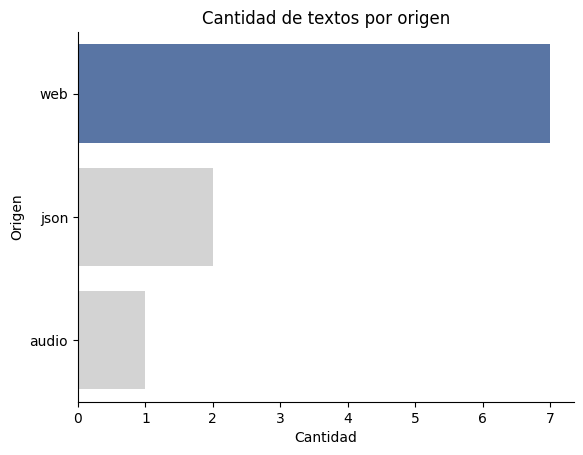

In [16]:
visualizar_origen(df_corpus_completo)

In [17]:
def visualizar_palabras_clave_lollipop(palabras_clave):
    import matplotlib.pyplot as plt

    plt.close('all')

    palabras = [p[0] for p in palabras_clave][::-1]
    valores = [p[1] for p in palabras_clave][::-1]

    fig, ax = plt.subplots()

    # líneas finitas (menos tinta)
    ax.hlines(y=palabras, xmin=0, xmax=valores, linewidth=1)

    # puntos más chicos
    ax.plot(valores, palabras, "o", markersize=5)

    ax.set_title("Palabras clave más frecuentes")
    ax.set_xlabel("Frecuencia")

    # clave: limpiar ruido visual
    ax.spines[['top', 'right']].set_visible(False)

    plt.show()

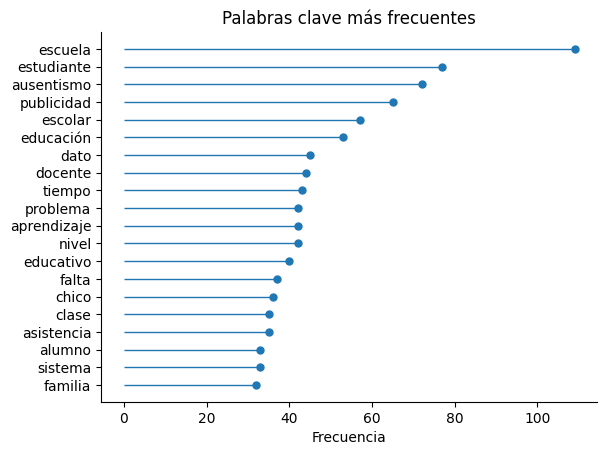

In [18]:
palabras_clave = analizador.extraer_palabras_clave()
visualizar_palabras_clave_lollipop(palabras_clave)

In [27]:
def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes"""
    fig = go.Figure()
    
    colores = {"PER": "#0072B2", "ORG": "#E69F00", "LOC": "#009E73"}
    
    for tipo in ["PER", "ORG", "LOC"]:
        datos = entidades_dict[tipo]
        if datos:
            nombres = list(datos.keys())
            valores = list(datos.values())
            fig.add_trace(go.Bar(
                name=tipo,
                x=nombres,
                y=valores,
                marker_color=colores[tipo]
            ))
    
    fig.update_layout(
        title="Entidades nombradas por tipo",
        barmode="group",
        template="plotly_white",
        xaxis_tickangle=-45,
        xaxis_tickfont=dict(size=10)
    )
    return fig

In [28]:
fig = visualizar_entidades_plotly(entidades)
fig.show()

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [ ]:
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None
        
    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""

        datos_web = extraer_noticias_web(self.urls_web) if self.urls_web else []
        datos_audio = transcribir_audio_youtube(self.url_audio) if self.url_audio else []
        datos_json = cargar_json_previo(self.ruta_json) if self.ruta_json else []

        self.df = unificar_corpus(datos_web, datos_audio, datos_json)

        self.analizador = AnalizadorCorpus(self.df)

        print("Pipeline ejecutado exitosamente.")
        
    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="estadisticas.json"):
        """Exporta el dataframe y un JSON analítico"""

        if self.df is None or self.analizador is None:
            print("Primero ejecutá el pipeline")
            return
        
        df_exportable = self.df.drop(columns=["doc"], errors="ignore")
        df_exportable.to_csv(ruta_csv, index=False, encoding="utf-8")
        print(f"CSV guardado: {ruta_csv}")
        
        reporte = {
            "estadisticas": self.analizador.estadisticas_corpus(),
            "entidades": self.analizador.extraer_entidades(),
            "verbos_principales": self.analizador.extraer_verbos_principales(),
            "palabras_clave": self.analizador.extraer_palabras_clave()
        }
        
        with open(ruta_json, "w", encoding="utf-8") as f:
            json.dump(reporte, f, ensure_ascii=False, indent=2)
        print("Archivos exportados correctamente.")

In [30]:
pipeline = PipelineMediatico(
    urls_web=urls,
    ruta_json="corpus_anterior.json"
)
pipeline.df = df_corpus_completo
pipeline.analizador = analizador

pipeline.generar_reporte_y_exportar()

CSV guardado: corpus_resultante.csv
Archivos exportados correctamente.


> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

C:\Users\cin_c\AppData\Local\Temp\ipykernel_7620\2092502478.py:4: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
C:\Users\cin_c\AppData\Local\Temp\ipykernel_7620\464801288.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


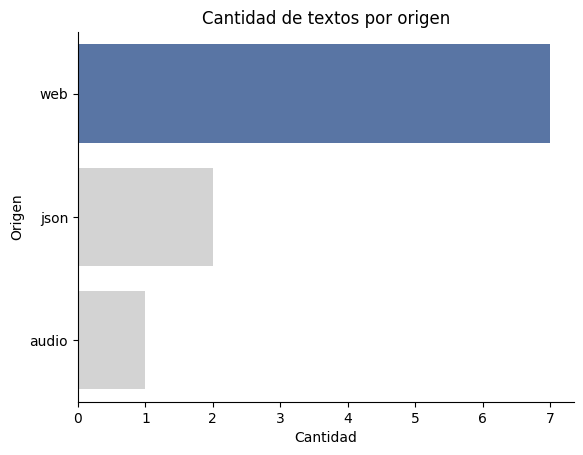

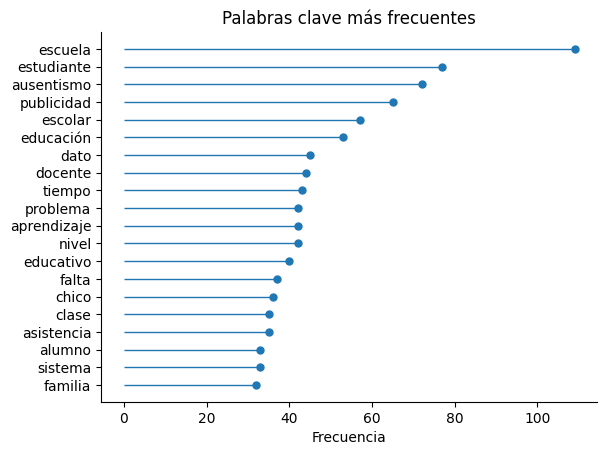

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


In [31]:
# PASO 1: Diseñá el bloque principal de gr.Blocks() interactuando con los métodos de la clase AnalizadorCorpus.
# Sugerencia: Utilizá pestañas (gr.Tab) para separar "Métricas Generales" de "Filtros e Interacción".

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# Explorador de Agenda Mediática")
    gr.Markdown("**Tema:** Ausentismo escolar en Argentina | **Fuentes:** Web, Audio, JSON")

    with gr.Tab("Panorama y Métricas"):
        gr.Markdown("## Métricas generales del corpus")
        
        with gr.Row():
            stats = analizador.estadisticas_corpus()
            gr.Textbox(value=str(stats["total_documentos"]), label="Total documentos")
            gr.Textbox(value=str(stats["total_tokens"]), label="Total tokens")
            gr.Textbox(value=str(stats["vocabulario_unico"]), label="Vocabulario único")
            gr.Textbox(value=str(stats["total_oraciones"]), label="Total oraciones")
        
        with gr.Row():
            gr.Plot(value=visualizar_origen(df_corpus_completo), label="Documentos por origen")
            gr.Plot(value=visualizar_palabras_clave_lollipop(analizador.extraer_palabras_clave()), label="Palabras clave")

    with gr.Tab("Explorador de Entidades"):
        gr.Markdown("## Entidades nombradas")
        gr.Plot(value=visualizar_entidades_plotly(analizador.extraer_entidades()), label="Entidades por tipo")
        
        gr.Markdown("## Buscador de entidades en el corpus")
        with gr.Row():
            entidad_input = gr.Textbox(label="Ingresá una entidad para buscar", placeholder="Ej: Argentina, Ministerio...")
            buscar_btn = gr.Button("Buscar")
        
        resultados_output = gr.Textbox(label="Oraciones donde aparece la entidad", lines=10)
        
        def buscar_entidad(entidad):
            if not entidad:
                return "Ingresá una entidad para buscar."
            resultados = []
            for _, fila in df_corpus_completo.iterrows():
                for sent in fila["doc"].sents:
                    if entidad.lower() in sent.text.lower():
                        resultados.append(f"[{fila['origen'].upper()}] {sent.text.strip()}")
            if not resultados:
                return f"No se encontró '{entidad}' en el corpus."
            return "\n\n".join(resultados[:10])
        
        buscar_btn.click(fn=buscar_entidad, inputs=entidad_input, outputs=resultados_output)

dashboard_medios.launch()

---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.